In [22]:
import pandas
from dataset import BraindumpDataset, split_dataset
from tokenizer import Tokenizer
import torch
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
df = pandas.read_csv("dataset_10000.csv")
df.head(10)

,input_text,target_text
0,Please remember to deploy the container and fi...,1. Deploy the container | 2. fix the leaky faucet
1,"I have to fix the leaky faucet, book the trave...",1. Fix the leaky faucet | 2. book the travel |...
2,"as we discussed, Please backup the photos, dep...",1. Backup the photos | 2. deploy the container...
3,"Please scan the receipts, test the new feature...",1. Scan the receipts | 2. test the new feature...
4,"the team needs, My tasks: Schedule a meeting w...",1. Schedule a meeting with luis | 2. water the...
5,"I have to update the repository, change the li...",1. Update the repository | 2. change the light...
6,"it's urgent, Please remember to charge the dev...",1. Charge the devices | 2. install the updates...
7,We have to configure the firewall and test the...,1. Configure the firewall | 2. test the new fe...
8,Don't forget to sweep the floor this weekend a...,1. Sweep the floor this weekend | 2. test the ...
9,Remind me to empty the recycle bin at noon and...,1. Empty the recycle bin at noon | 2. do the l...


In [24]:
all_text = " ".join(df['input_text'].astype(str).tolist() + df['target_text'].astype(str).tolist())
tokenizer = Tokenizer(all_text)

In [25]:
for input_text, target_text in zip(df['input_text'], df['target_text']):
    input_ids = tokenizer.encode(input_text)
    target_ids = tokenizer.encode(target_text)
    inputs_words = tokenizer.decode(input_ids)
    print(f"Input IDs: {input_ids}")
    print(f"Target IDs: {target_ids}")
    print(f"Input words: {inputs_words}")
    break
    

Input IDs: [179, 196, 237, 72, 233, 63, 17, 99, 233, 137, 93, 2]
Target IDs: [3, 2, 72, 233, 63, 265, 4, 2, 99, 233, 137, 93]
Input words: please remember to deploy the container and fix the leaky faucet.


In [26]:
def encode_row(text):
    return tokenizer.encode(text)

df['input_ids'] = df['input_text'].apply(encode_row)
df['target_ids'] = df['target_text'].apply(encode_row)
dataset = BraindumpDataset(df)


In [27]:
tokenizer.decode(df['input_ids'][2]), df['input_text'][2]

('as we discussed, please backup the photos, deploy the container, and schedule a meeting with el cliente.',
 'as we discussed, Please backup the photos, deploy the container, and schedule a meeting with el cliente.')

In [28]:
tokenizer.decode(df['target_ids'][2]), df['target_text'][2]

('1. backup the photos | 2. deploy the container | 3. meet with el cliente',
 '1. Backup the photos | 2. deploy the container | 3. Meet with el cliente')

In [29]:
#Need to Add Padding becuase there is a difference in Sequence Lenght input vs label
print(len(dataset[1][0]), len(dataset[1][1]))

19 18


In [30]:
train_dataset, val_dataset, test_dataset = split_dataset(dataset, 32)

In [31]:
trainer_loader = iter(train_dataset)
batch_trainer = next(trainer_loader)
[len(i) for i in batch_trainer['tokenized_input']][0], [len(i) for i in batch_trainer['label']][0]

(26, 21)

In [32]:
validation_loader = iter(val_dataset)
batch2 = next(validation_loader)
[len(i) for i in batch2['tokenized_input']][0], [len(i) for i in batch2['label']][0]

(23, 19)

In [33]:
test_loader = iter(test_dataset)
batch_test = next(test_loader)
[len(i) for i in batch_test['tokenized_input']][0], [len(i) for i in batch_test['label']][0]

(30, 22)

## Training the Model Seq2Seq

In [34]:
from models.seq2seq_attention import EncoderAttention, DecoderAttention, Attention, Seq2SeqAttention
import torch.nn as nn
import torch.optim as optim
from utils import init_weights_attention, plot_weights_initialization, count_parameters_model
import tqdm as notebook_tqdm
import tqdm
import numpy as np

In [35]:
input_dim = tokenizer.get_vocab_size()
output_dim = tokenizer.get_vocab_size()
assert input_dim == output_dim, "Encoder and Decoder must have the same vocabulary size because they share the same tokenizer"


encoder_embedding_dim = 128
decoder_embedding_dim = 128

encoder_hidden_dim = 312
decoder_hidden_dim = 312

num_layers = 3

encoder_dropout = 0.4
decoder_dropout = 0.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim=encoder_hidden_dim, decoder_hidden_dim=decoder_hidden_dim)

encoder = EncoderAttention(
    input_dim=input_dim,
    embedding_dim=encoder_embedding_dim,
    num_layers=num_layers,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=encoder_dropout
)

decoder = DecoderAttention(
    output_dim=output_dim,
    embedding_dim=decoder_embedding_dim,
    num_layers=num_layers,
    encoder_hidden_dim=encoder_hidden_dim,
    decoder_hidden_dim=decoder_hidden_dim,
    dropout=decoder_dropout,
    attention=attention
)

Seq2Seq_model_Attention = Seq2SeqAttention(
    encoder=encoder,
    decoder=decoder,
    device=device
)

### Weight initialization

In the paper the state the initialization of the weights are transformed in the Uniform/Gaussian distribution so the weights doesnt explode with the the tahn, making the gradients doesnt have Vanish Gradient

and with the biases are converted to zero, so it updates with the weights


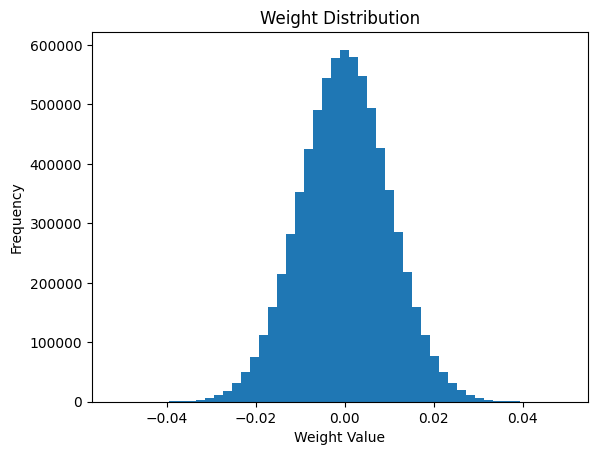

Seq2SeqAttention(
  (encoder): EncoderAttention(
    (embedding): Embedding(268, 128)
    (rnn): GRU(128, 312, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
    (fc): Linear(in_features=624, out_features=312, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
  (decoder): DecoderAttention(
    (attention): Attention(
      (attn_fc): Linear(in_features=936, out_features=312, bias=True)
      (v_fc): Linear(in_features=312, out_features=1, bias=False)
    )
    (embedding): Embedding(268, 128)
    (rnn): GRU(752, 312, num_layers=3, batch_first=True, dropout=0.4)
    (fc_out): Linear(in_features=1064, out_features=268, bias=True)
    (dropout): Dropout(p=0.4, inplace=False)
  )
)

In [36]:
Seq2Seq_model_Attention.apply(init_weights_attention)

plot_weights_initialization(Seq2Seq_model_Attention) #Plot initialization for seeing the distribution of the weihgts

Seq2Seq_model_Attention    

In [42]:
sum_parameters = count_parameters_model(Seq2Seq_model_Attention)
print(f"The total parameters of the model {sum_parameters}")


The total parameters of the model 7350628


#### Optimizer

In [43]:
optimizer = optim.AdamW(Seq2Seq_model_Attention.parameters(), weight_decay=0.001)

#### Loss Function

The CrossEntropyLoss function calculates both the log softmax as well as the negative log-likelihood of our predictions.

In [44]:
pad_idx = 0 #Its zero because in the custom_collate, I'm adding 0's for the padding of the sequences
criterion = nn.CrossEntropyLoss(ignore_index = pad_idx)

#### Training Loop

At each iteration:

1. Get the source and target sentences from the batch, and zero the gradients calculated from the last batch.
2. Feed the source and target into the model to get the output.
3. As the loss function only works on 2D inputs with 1D targets, we need to flatten each of them with `.view`.
4. We slice off the first column of the output and target tensors as mentioned above.
5. Calculate the gradients with `loss.backward()`.
6. Clip the gradients to prevent them from exploding (a common issue in RNNs).
7. Update the parameters of our model by doing an optimizer step.
8. Sum the loss value to a running total.

In [45]:
from utils import train_fuction, validation_fuction
from EarlyStopping import EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
n_epochs = 20
clip = 1.0
teacher_forcing_ratio = 0.5
best_valid_loss = float('inf')
train_losses = []
validation_losses = []
earlystopping = EarlyStopping(patience=2, mode="min", path="best_attention_model.pt", verbose=True)

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fuction(
        Seq2Seq_model_Attention,
        train_dataset,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device)
    validation_loss = validation_fuction(
        Seq2Seq_model_Attention,
        val_dataset,
        criterion,
        device
    )
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    
    earlystopping(validation_loss, Seq2Seq_model_Attention)
    
    
    print(f"Train Loss: {train_loss:7.3f} - Train PPL: {np.exp(train_loss):7.3f}")
    print(f"Valid Loss: {validation_loss:7.3f} - Valid PPL: {np.exp(validation_loss):7.3f}")
    
    if earlystopping.early_stop:
        print("Finished because of the early Stopping")
        break

earlystopping.load_best_weights(Seq2Seq_model_Attention)

  5%|▌         | 1/20 [03:57<1:15:14, 237.61s/it]

New best metric for trace model 0.4693 -> New model
Train Loss:   0.510 - Train PPL:   1.665
Valid Loss:   0.469 - Valid PPL:   1.599


 10%|█         | 2/20 [06:32<56:38, 188.81s/it]  

New best metric for trace model 0.4229 -> New model
Train Loss:   0.455 - Train PPL:   1.576
Valid Loss:   0.423 - Valid PPL:   1.526


 15%|█▌        | 3/20 [10:26<59:22, 209.57s/it]

...

New best metric for trace model 0.4057 -> New model
Train Loss:   0.410 - Train PPL:   1.507
Valid Loss:   0.406 - Valid PPL:   1.500


 45%|████▌     | 9/20 [30:58<37:27, 204.31s/it]

EarlyStopping counter 1/2
Train Loss:   0.412 - Train PPL:   1.510
Valid Loss:   0.408 - Valid PPL:   1.504


 50%|█████     | 10/20 [34:28<34:22, 206.21s/it]

New best metric for trace model 0.3988 -> New model
Train Loss:   0.412 - Train PPL:   1.511
Valid Loss:   0.399 - Valid PPL:   1.490


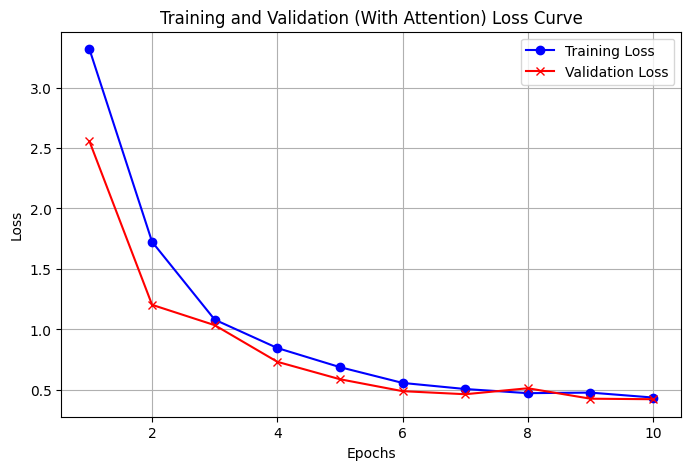

In [22]:
epochs_range = range(1, n_epochs + 1)


plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, validation_losses, label='Validation Loss', color='red', marker='x')

plt.title('Training and Validation (With Attention) Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluating the model

In [23]:
from rouge_score import rouge_scorer
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
Seq2Seq_model_Attention.load_state_dict(torch.load("best_attention_model.pt", map_location=device))
test_loss = validation_fuction(Seq2Seq_model_Attention,
        val_dataset,
        criterion,
        device)


print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

| Test Loss: 0.423 | Test PPL:   1.527 |


In [ ]:
import torch

def extract_summary(
    sentence, 
    model, 
    tokenizer,              # Pasas directamente tu instancia de Tokenizer
    device="cpu", 
    max_output_length=50,
    repetition_penalty=1.2
):
    model.eval()
    
    # 1. Codificar usando tu método encode()
    input_ids = tokenizer.encode(sentence)
    
    # Obtener el ID del token especial de fin/inicio (<|endoftext|>)
    eos_idx = tokenizer.text_to_token_ids.get("<|endoftext|>", 0)
    
    # Estructurar la entrada con el token especial al inicio y al final
    src_indexes = [eos_idx] + input_ids + [eos_idx]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)  # Shape: [1, seq_len]

    # 2. Pasar por el Encoder
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    # 3. Bucle de generación (Decoder con Penalty)
    inputs = [eos_idx]
    
    for _ in range(max_output_length):
        trg_tensor = torch.LongTensor([inputs[-1]]).to(device)
        
        with torch.no_grad():
            output, hidden, _ = model.decoder(trg_tensor, hidden, encoder_outputs)
            
        logits = output[0]
        
        # Penalización de repetición para evitar bucles infinitos
        for token_id in set(inputs):
            if logits[token_id] < 0:
                logits[token_id] *= repetition_penalty
            else:
                logits[token_id] /= repetition_penalty
                
        pred_token_idx = logits.argmax(0).item()
        
        if pred_token_idx == eos_idx:
            break
            
        inputs.append(pred_token_idx)

    # 4. Decodificar la salida omitiendo el token inicial con tu método decode()
    generated_ids = inputs[1:]
    return tokenizer.decode(generated_ids)

### Without Attention

In [32]:
frases = [
    "Schedule a meeting with Sarah by Friday and remember to run the database backup",
    "Buy milk, eggs, and bread from the grocery store tomorrow morning"
]

for texto in frases:
    tokens = extract_summary(
        sentence=texto,
        model=Seq2Seq_model_Attention,
        src_nlp=tokenizer,                      
        src_vocab=tokenizer.text_to_token_ids,  
        trg_vocab=tokenizer.text_to_token_ids,  
        sos_token="<unk>",                      
        eos_token="<|endoftext|>",              
        device=device
    )
    print(f"Entrada: {texto}")
    print(f"Salida:  {' '.join(tokens)}\n")

Entrada: Schedule a meeting with Sarah by Friday and remember to run the database backup
Salida:  . schedule meeting with sarah by friday | 2 . run the database backup on tuesday pm run the database backup backup friday pm run run the database backup on tuesday pm run the database backup backup friday pm run the database backup backup on tuesday pm run the database

Entrada: Buy milk, eggs, and bread from the grocery store tomorrow morning
Salida:  . buy the repository | 2 . clean the client repository at . update the repository repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight . update the repository at midnight .



In [25]:
predictions = []
references = []

for batch in test_loader:
    # 1. Extraer los tensores del batch
    input_ids_batch = batch['tokenized_input']  # O la clave que contenga las entradas
    target_ids_batch = batch['label']       # O la clave que contenga los targets
    
    # 2. Iterar sobre cada elemento del batch
    for input_ids, target_ids in zip(input_ids_batch, target_ids_batch):
        
        # Convertir Tensor a lista y decodificar a String
        if isinstance(input_ids, torch.Tensor):
            input_text = tokenizer.decode(input_ids.tolist())
        else:
            input_text = input_ids

        if isinstance(target_ids, torch.Tensor):
            target_text = tokenizer.decode(target_ids.tolist())
        else:
            target_text = target_ids

        # 3. Inferencia con extract_summary
        tokens_pred = extract_summary(
            sentence=input_text,
            model=Seq2Seq_model,
            src_nlp=tokenizer,
            src_vocab=tokenizer.text_to_token_ids,
            trg_vocab=tokenizer.text_to_token_ids,
            sos_token="<unk>",
            eos_token="<|endoftext|>",
            device=device
        )
        
        predictions.append(" ".join(tokens_pred))
        references.append(target_text)

In [ ]:
import evaluate

rouge = evaluate.load('rouge')
bleu = evaluate.load('bleu')


rouge_results = rouge.compute(
    predictions=predictions, 
    references=references,
    use_stemmer=True
)


bleu_results = bleu.compute(
    predictions=predictions, 
    references=references
)

In [28]:
print("--- Rogue Results---")
rouge_results

--- Rogue Results---


{'rouge1': 0.376813055221071,
 'rouge2': 0.22634177519722903,
 'rougeL': 0.3640130993844639,
 'rougeLsum': 0.36413509606233363}

In [29]:
print("\n--- Blue Results ---")
bleu_results


--- Blue Results ---


{'bleu': 0.21510804279655596,
 'precisions': [0.3405982905982906,
  0.24410551134689065,
  0.18711843711843712,
  0.13762266540044318],
 'brevity_penalty': 1.0,
 'length_ratio': 1.5135834411384217,
 'translation_length': 14040,
 'reference_length': 9276}